In [1]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3
from scoob_llowfsc import utils
from scoob_llowfsc import llowfsc_sim as llowfsc
import scoob_llowfsc.scoob_model as scoobm
import scoob_llowfsc.detector as detector

wfe_data = utils.load_pickle('sim-data/example_wfe_data.pkl')
iefc_data = utils.load_pickle('sim-data/example_iefc_data.pkl')
dh_command = iefc_data['commands'][-1]

# hadamard_svd_data = {
#     'control_modes':control_modes,
#     'wfs_modes':wfs_modes,
#     'singular_values':s, 
#     'defocus':M.llowfsc_defocus,
# }

hadamard_svd_data = utils.load_pickle('sim-data/llowfsc_hadamard_svd_data.pkl')
hsvd_dm_modes = hadamard_svd_data['control_modes']
hsvd_wfs_modes = hadamard_svd_data['wfs_modes']

reload(detector)
CAMLO = detector.DETECTOR(exp_time=0.001, throughput=0.02, blacklevel=100, read_noise=2, gain=4)

nominal_flux = 5.65e10 * u.ph/u.s/u.m**2

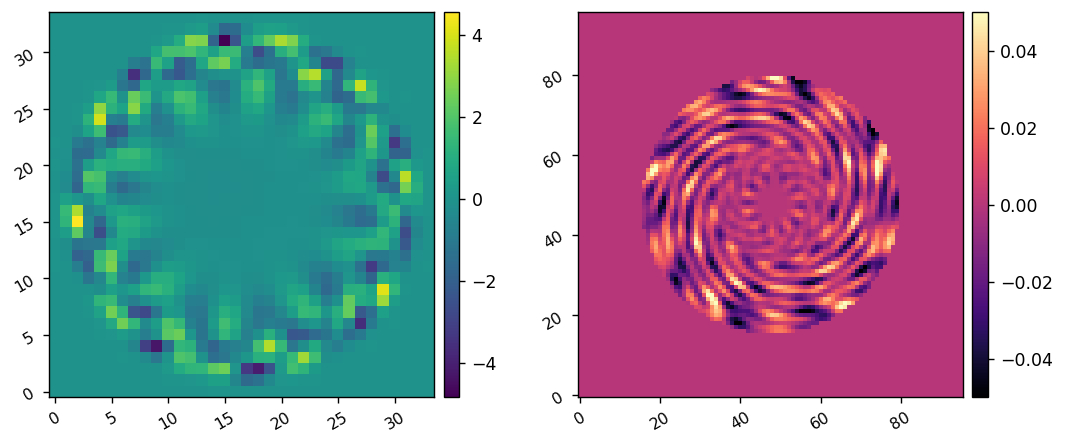

In [2]:
i = 100
vmax = 0.05
imshow2(
    hsvd_dm_modes[i], hsvd_wfs_modes[i], 
    cmap1='viridis', 
    vmin2=-vmax, vmax2=vmax,
)

Oversampling > 2x suggested for reliable results in Fresnel propagation.


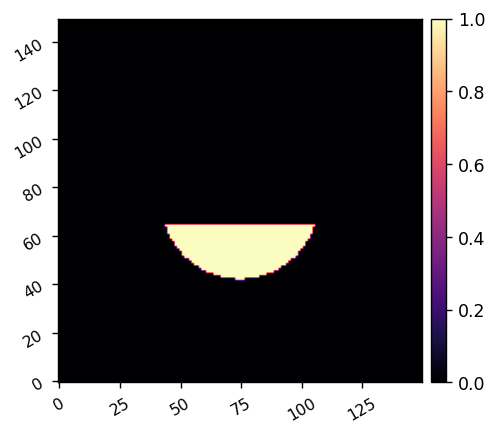

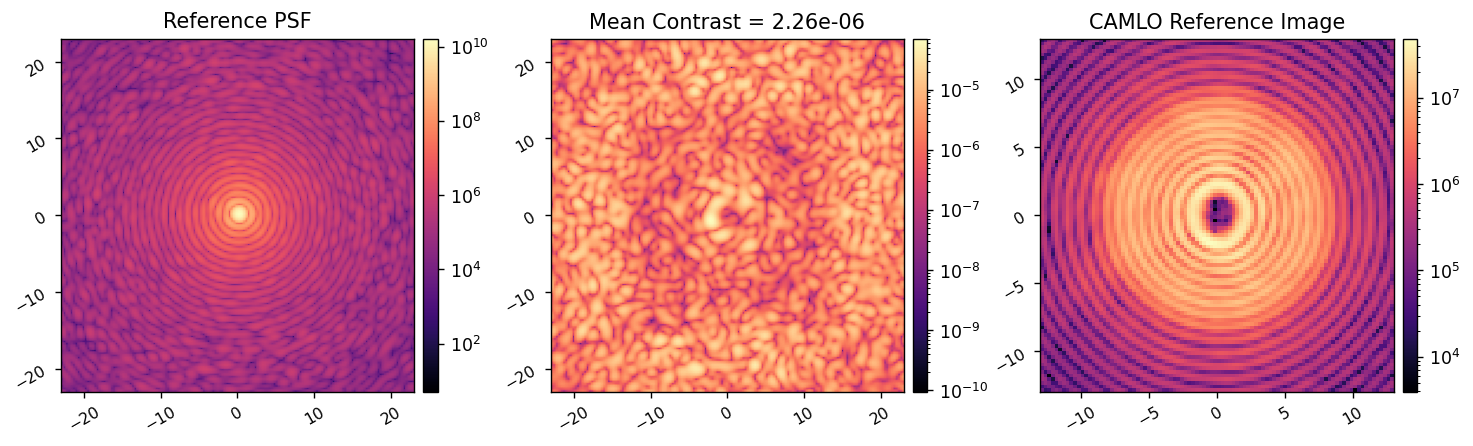

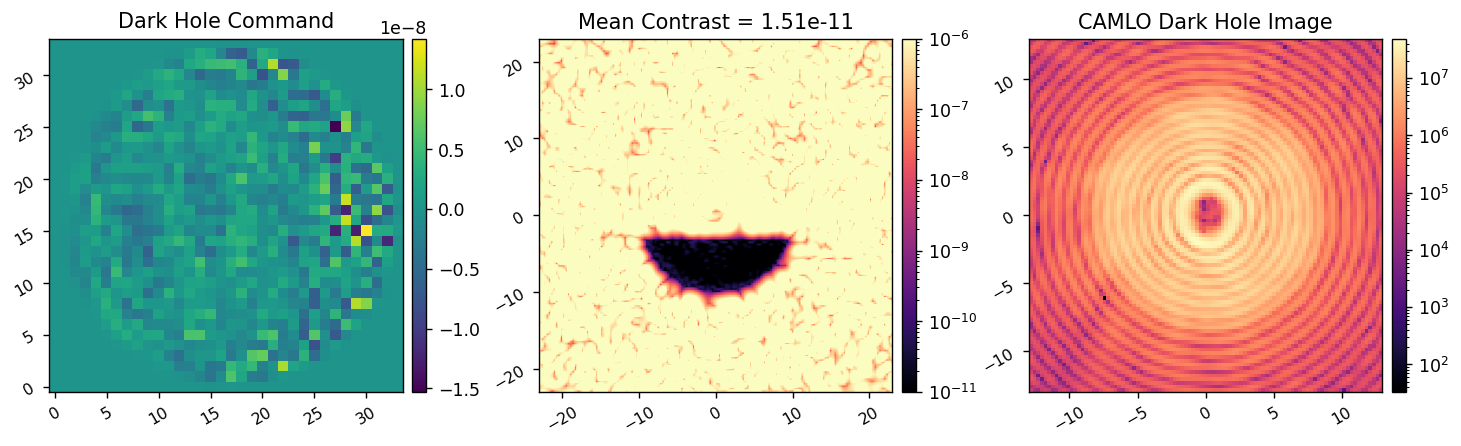

In [32]:
reload(scoobm)
reload(utils)

M = scoobm.single(
    dm_ref=wfe_data['DM_FLAT'],
    entrance_flux=nominal_flux, 
)
M.reset_dm()
M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']

M.POSTFPM_AMP = wfe_data['POSTFPM_AMP']
M.POSTFPM_OPD = wfe_data['POSTFPM_OPD']

M.RLS_AMP = wfe_data['RLS_AMP']
M.RLS_OPD = wfe_data['RLS_OPD']

iwa = 3
owa = 10
dark_hole_mask = utils.create_annular_focal_plane_mask(
    M.ncamsci, 
    M.camsci_pxscl_lamD, 
    iwa, 
    owa,  
    edge=iwa,
    rotation=90,
)
imshow1(dark_hole_mask)

M.use_vortex = 0
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
camsci_im_ref = M.snap_camsci()
contrast_ref = xp.mean(camsci_im_ref[dark_hole_mask])

# M.CAMLO = CAMLO
# M.NCAMLO = 100

M.llowfsc_defocus = 2.75*u.mm
# M.llowfsc_defocus = 4.75*u.mm
camlo_im_ref = M.snap_camlo()

imshow3(
    ref_psf, camsci_im_ref, camlo_im_ref,
    'Reference PSF', f'Mean Contrast = {contrast_ref:.2e}', 'CAMLO Reference Image',
    pxscl1=M.camsci_pxscl_lamDc, pxscl2=M.camsci_pxscl_lamDc, pxscl3=M.camlo_pxscl_lamDc,
    lognorm=1, 
)

M.add_dm(dh_command, 3)
camsci_im_dh0 = M.snap_camsci()
contrast_dh0 = xp.mean(camsci_im_dh0[dark_hole_mask])
camlo_im_dh = M.snap_camlo()
M.add_dm(-dh_command, 3)

imshow3(
    dh_command, camsci_im_dh0, camlo_im_dh,
    'Dark Hole Command', f'Mean Contrast = {contrast_dh0:.2e}', 'CAMLO Dark Hole Image',
    pxscl2=M.camsci_pxscl_lamDc, pxscl3=M.camlo_pxscl_lamDc,
    cmap1='viridis',
    lognorm2=1, vmin2=1e-11, vmax2=1e-6,
    lognorm3=1,
)


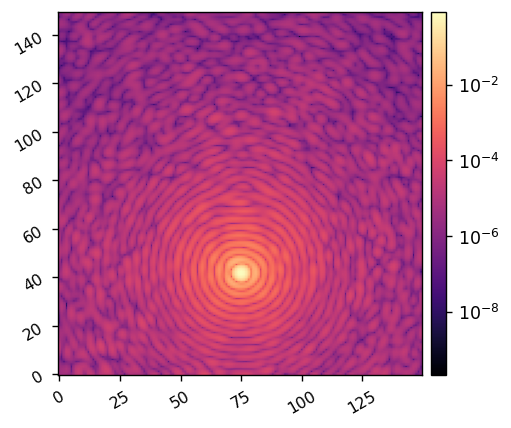

In [43]:
M.zero_fsm()
# M.set_fsm(np.array([0,0,-0.350]))
M.add_fsm(np.array([0,0,-100]))

M.reset_dm()
M.add_dm(dh_command, 3)

camsci_im = M.snap_camsci()
imshow1(
    camsci_im, 
    lognorm=1, 
    # vmin=1e-11, vmax=1e-6,
)

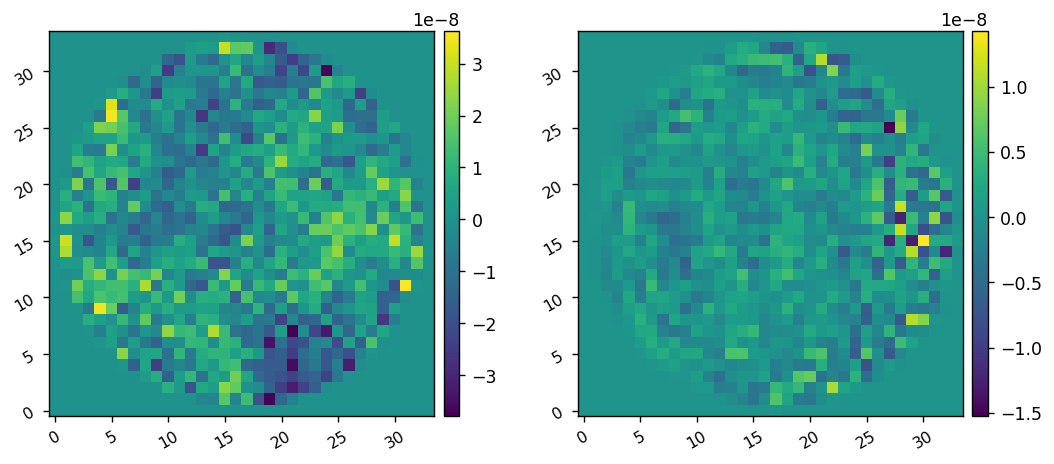

In [4]:
imshow2(wfe_data['DM_FLAT'], dh_command, cmap1='viridis', cmap2='viridis',)

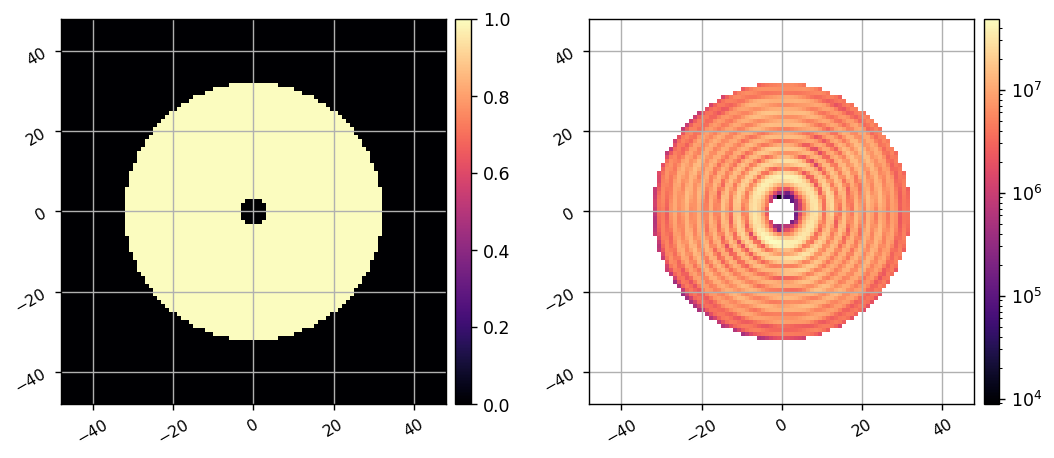

In [5]:
reload(llowfsc)
irad = 3
orad = 32
llowfsc_mask = utils.create_annular_focal_plane_mask(M.ncamlo, 1, irad, orad, edge=None, )
imshow2(llowfsc_mask, camlo_im_ref * llowfsc_mask, grid=True, pxscl=1, lognorm2=True)

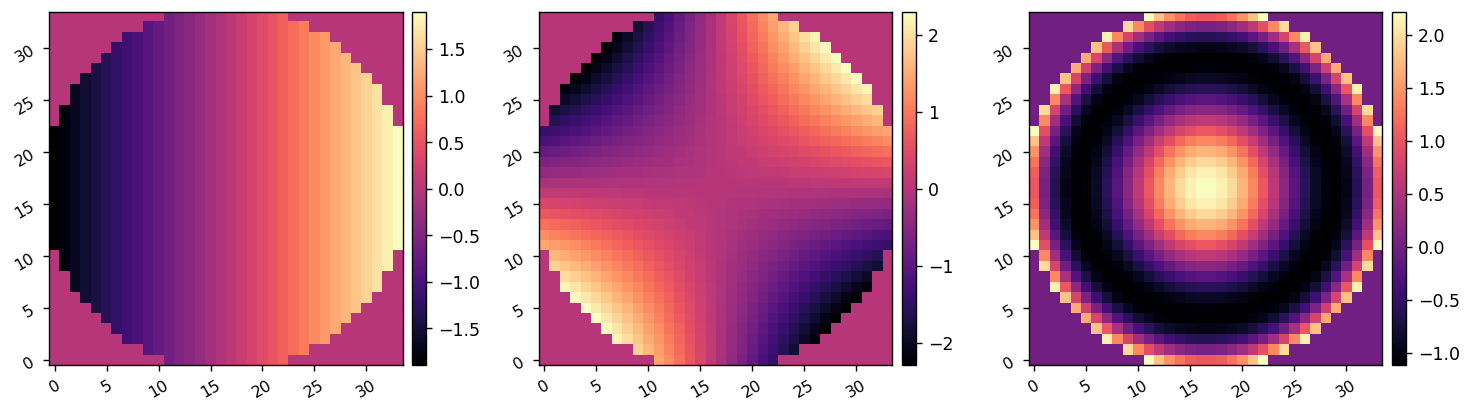

In [6]:
reload(utils)
zernike_modes = utils.create_zernike_modes(M.dm_mask, nmodes=10, remove_modes=1)
zer_modal_matrix = zernike_modes[:, M.dm_mask]
imshow3(zernike_modes[0], zernike_modes[3], zernike_modes[-1])

In [7]:
reload(llowfsc)
M.reset_dm()

M.NCAMLO = 100

M.setattr('use_vortex', True)
z_rm, z_response_cube = llowfsc.calibrate_without_fsm(
    M, 
    zernike_modes, 
    llowfsc_mask, 
    amps=1e-9, 
    # plot=True,
)

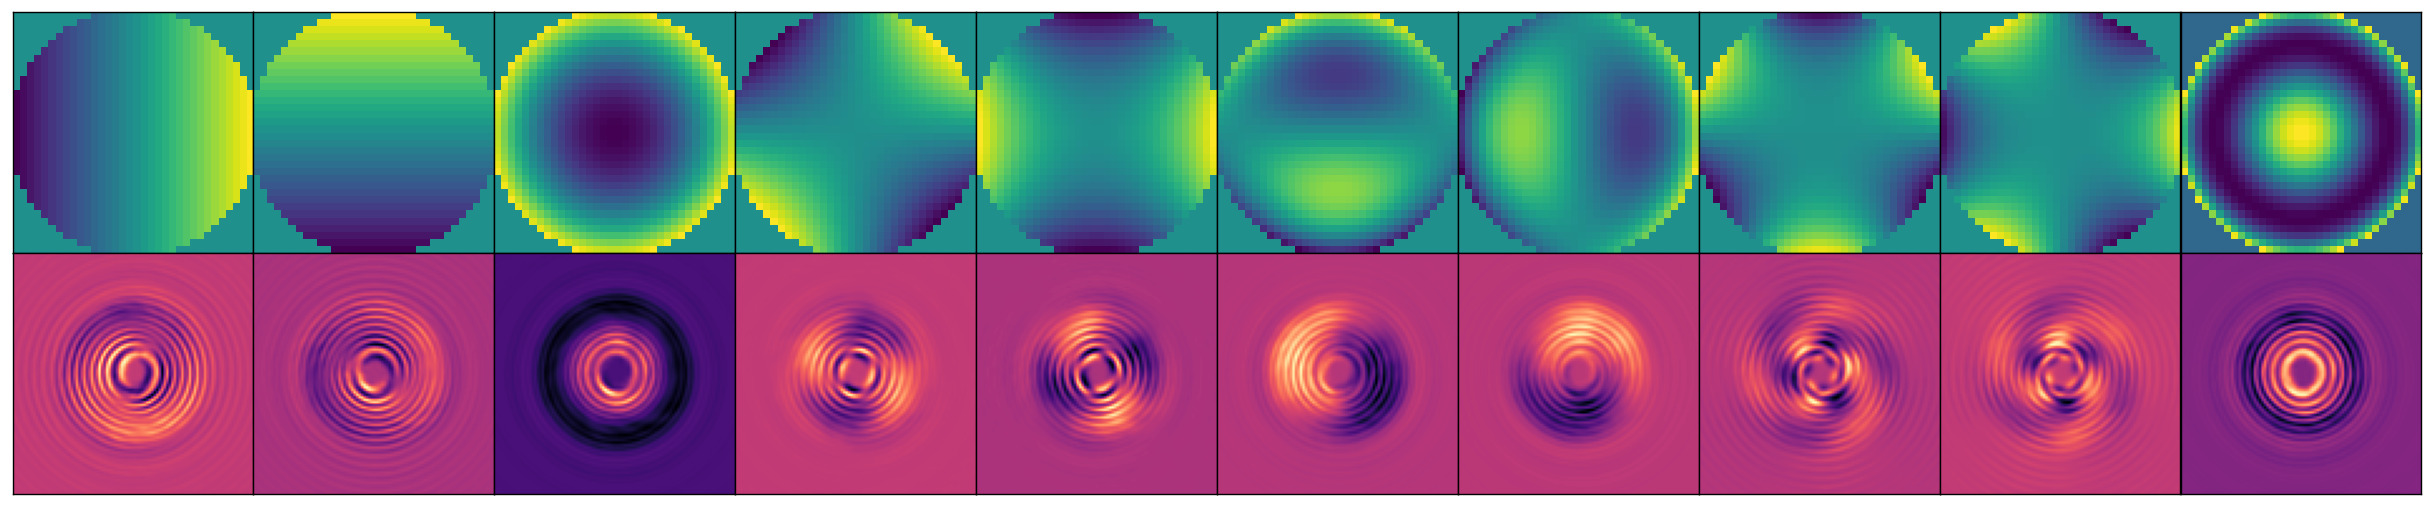

In [30]:
reload(llowfsc)
llowfsc.plot_responses(zernike_modes, z_response_cube)
# llowfsc.plot_responses(zernike_modes[10:], z_response_cube[10:])

In [31]:
control_matrix = utils.TikhonovInverse(z_rm, 0)

In [8]:
reload(llowfsc)
M.reset_dm()
M.setattr('use_vortex', True)

M.NCAMLO = 100

Ncutoff = 256
hsvd_control_modes = hsvd_dm_modes[:Ncutoff]
hsvd_modal_matrix = hsvd_control_modes[:, M.dm_mask]

hsvd_rm, hsvd_response_cube = llowfsc.calibrate_without_fsm(
    M, 
    hsvd_control_modes, 
    llowfsc_mask, 
    amps=3e-9, 
    # plot=True,
)


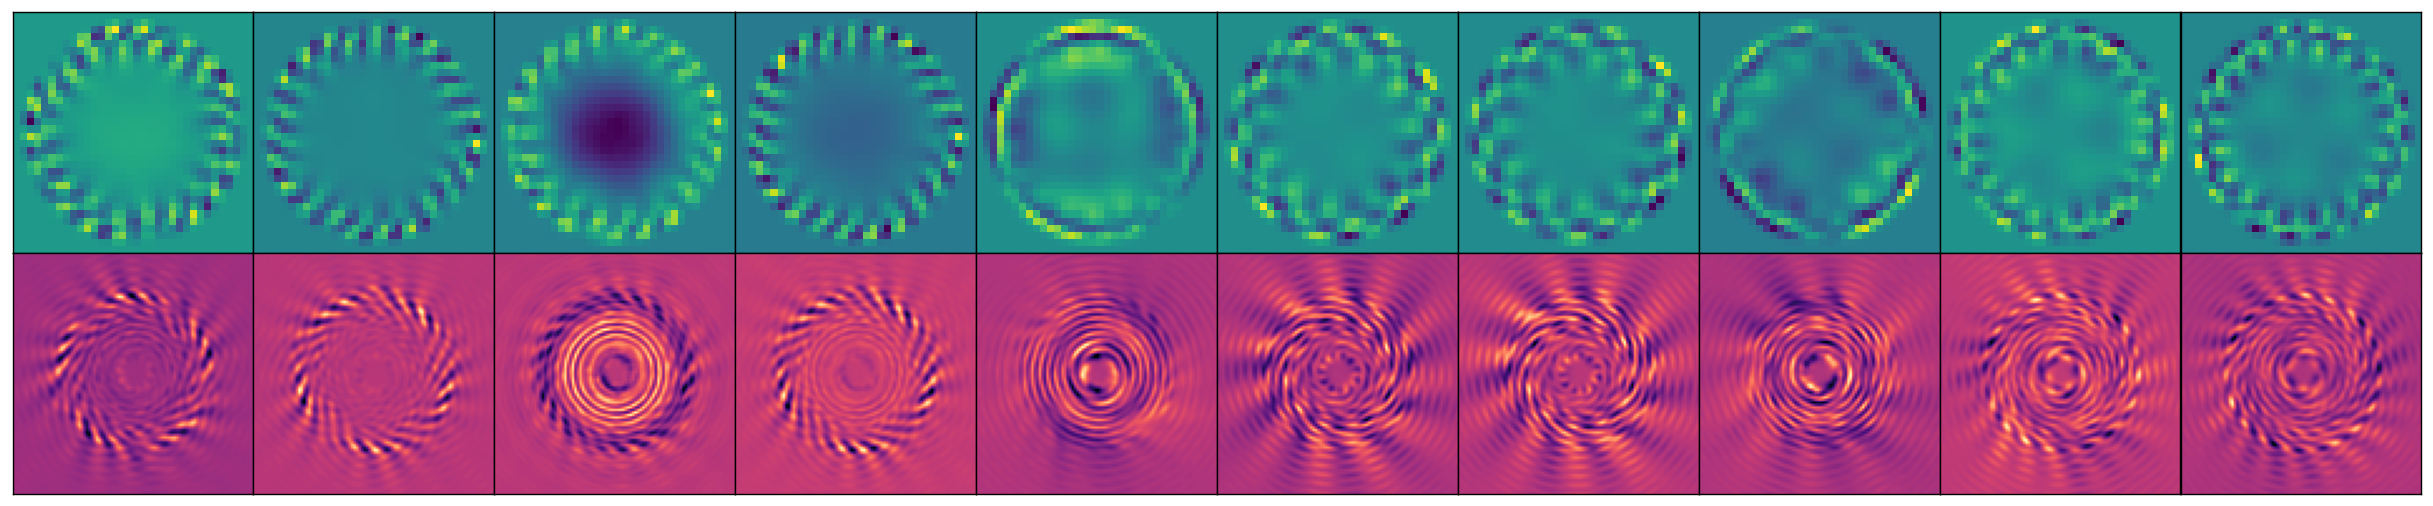

In [9]:
reload(llowfsc)
istart = 103
llowfsc.plot_responses(hsvd_control_modes[istart:], hsvd_response_cube[istart:])

29.0888208681574 nm
0.0005
0.004 250.0
(10, 1251)


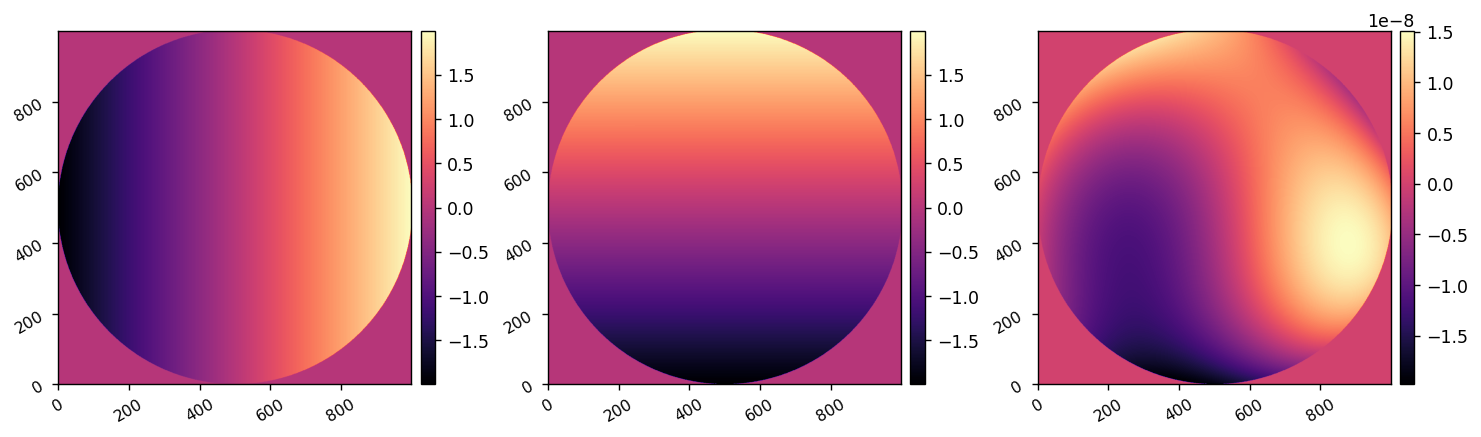

In [14]:
from scoob_llowfsc import psds
import copy
reload(psds)

total_pupil_diam = 2.4*u.m
dm_beam_diam = 9.1*u.mm
jitter = 10*u.mas 

fmax = 1000*u.Hz
tmax = 5*u.s
# tmax = 1*u.hour
# tmax = 5*u.hour

mag = (total_pupil_diam / dm_beam_diam).decompose().value
tt_pv_to_rms = 1/4
tt_at_pupil_pv = np.tan(mag*jitter).value * dm_beam_diam
tt_at_pupil_rms = tt_at_pupil_pv * tt_pv_to_rms
print(tt_at_pupil_rms.to(u.nm))

# wfe_modes_rms = np.array(2*[tt_at_pupil_rms.to_value(u.m)] + 8*[2.5e-9])
wfe_modes_rms = np.array(2*[10e-9] + 8*[2.5e-9])
# knee_freqs = np.array([0.1]*2 + [0.01]*8) * u.Hz
knee_freqs = np.array([1]*2 + [0.01]*8) * u.Hz
slope = 4

N_wfe_modes = len(wfe_modes_rms)
wfe_modes = utils.create_zernike_modes(M.APERTURE, nmodes=N_wfe_modes, remove_modes=1)

freqs, times = psds.generate_freqs(Nf=2**22+1, f_max=fmax)
delT = times[1] - times[0]

wfe_psds = xp.zeros((N_wfe_modes, len(freqs)))
wfe_time_series = xp.zeros((N_wfe_modes, len(times)))
seeds = 123 + np.linspace(0, N_wfe_modes-1, N_wfe_modes).astype(int)
for i in range(N_wfe_modes):
    f_knee = knee_freqs[i]
    psd = psds.kneePSD(freqs, 1, f_knee.to_value(u.Hz), slope)
    wfe_psds[i] = copy.copy(psd)
    coeff = psds.generate_time_series(psd, fmax, rms=1, seed=seeds[i])
    sign = 1 if xp.random.randn(1)>0 else -1
    wfe_time_series[i] = wfe_modes_rms[i] * sign * xp.array(coeff)

buffer = 0.0001
wfe_time_series = wfe_time_series[:, times<tmax.to_value(u.s)+buffer]
times = times[times<tmax.to_value(u.s)+buffer]
delT = times[1] - times[0]
print(delT)

# times, wfe_time_series = (times[::4], wfe_time_series[:, ::4])
times, wfe_time_series = (times[::8], wfe_time_series[:, ::8])
delT = times[1] - times[0]
print(delT, 1/delT)

print(wfe_time_series.shape)

lo_wfe = xp.sum( wfe_time_series[:, 500, None, None] * wfe_modes, axis=0)
imshow3(wfe_modes[0], wfe_modes[1], lo_wfe)

/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/psds.py:149: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0].set_xlim(psd_xlims)


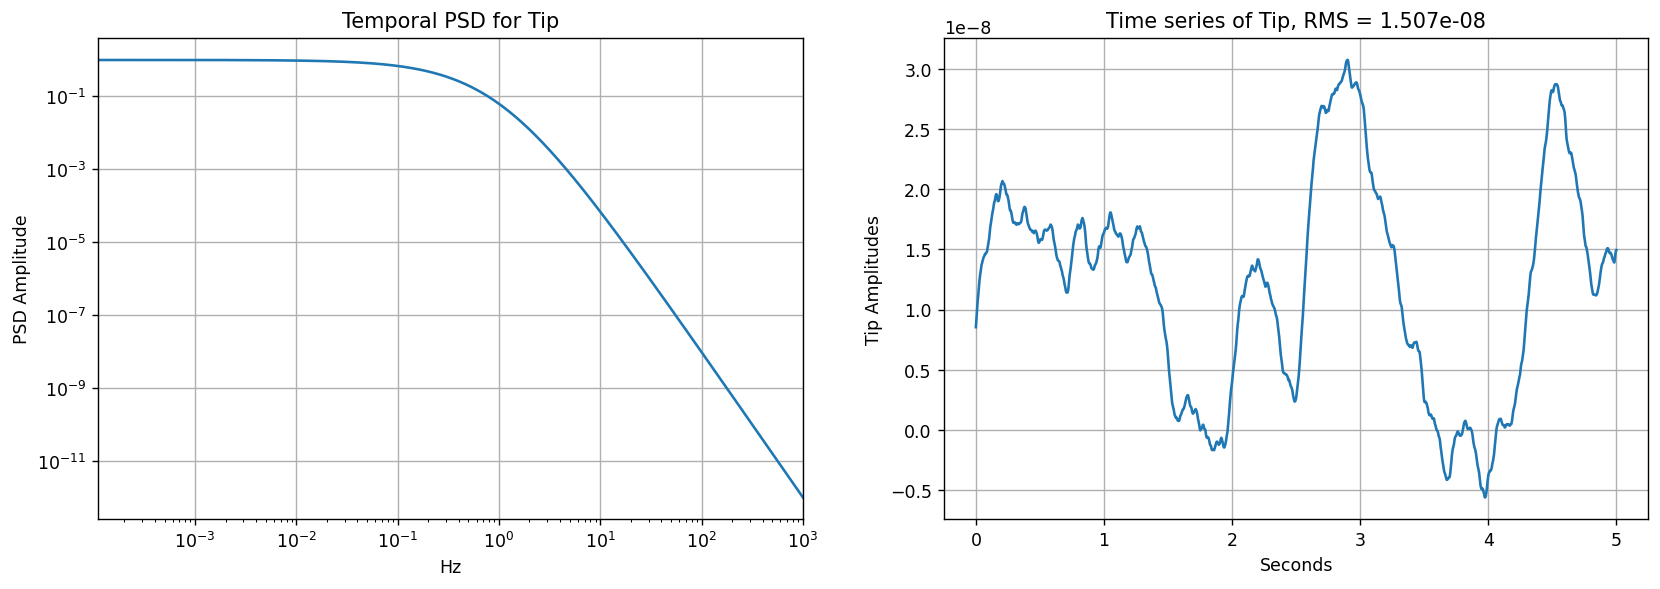

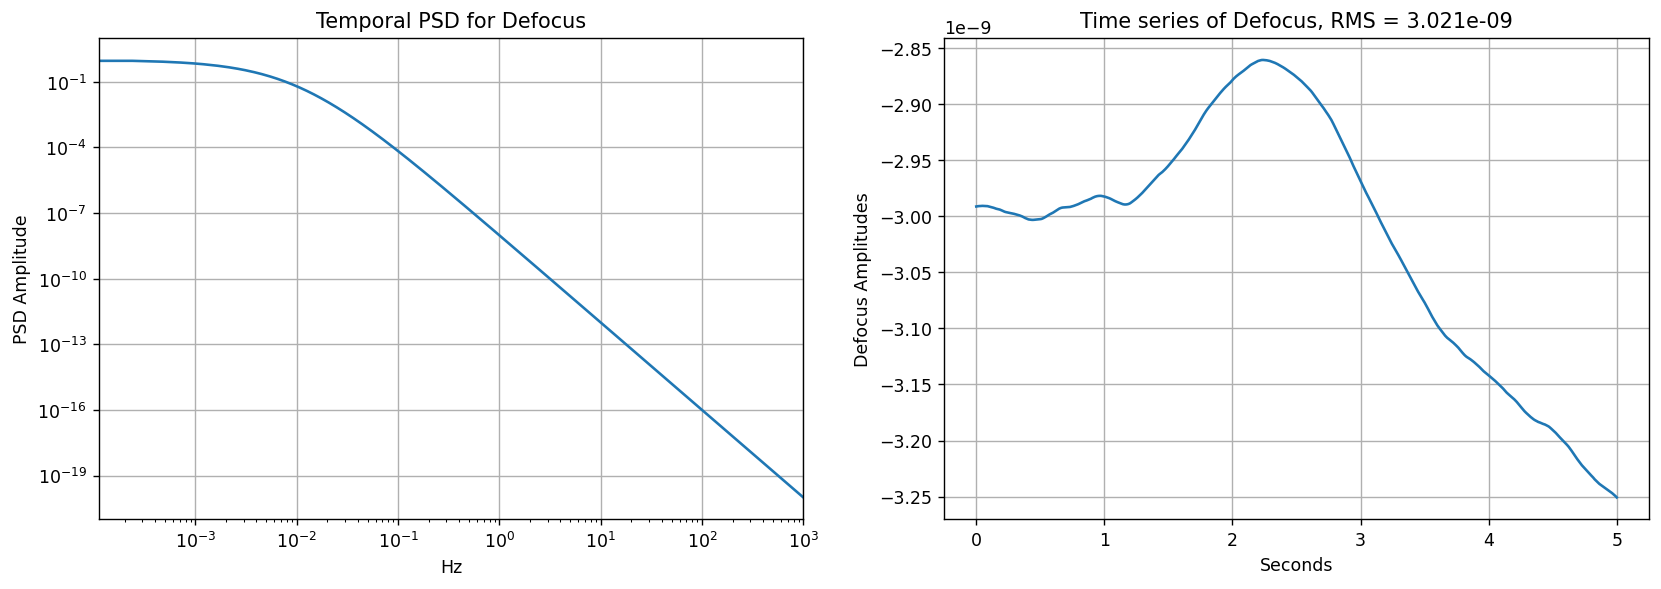

In [15]:
reload(psds)
i = 1
psd = wfe_psds[i]
coeff = wfe_time_series[i]

psds.plot_psd_and_time_series(
    freqs, psd,
    times, coeff,
    psd_name='for Tip',
    coeff_name='Tip',
    psd_xlims=[freqs.min(), 1000],
    # coeff_xlims=[0, 3600],
    # coeff_xticks=np.arange(0,3600+1,600),
    figsize=(16,5),
)

i = 3
psd = wfe_psds[i]
coeff = wfe_time_series[i]

psds.plot_psd_and_time_series(
    freqs, psd,
    times, coeff,
    psd_name='for Defocus',
    coeff_name='Defocus',
    psd_xlims=[freqs.min(), 1000],
    # coeff_xlims=[0, 3600],
    # coeff_xticks=np.arange(0,3600+1,600),
    figsize=(16,5),
)

In [32]:
wfe_modes = utils.create_zernike_modes(M.APERTURE, nmodes=10, remove_modes=1)

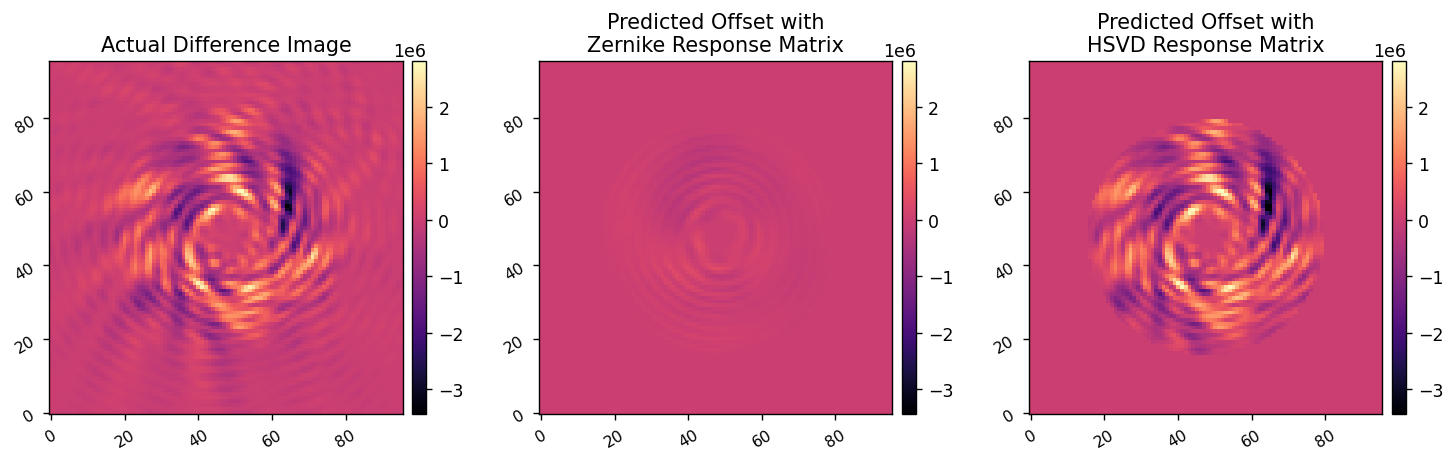

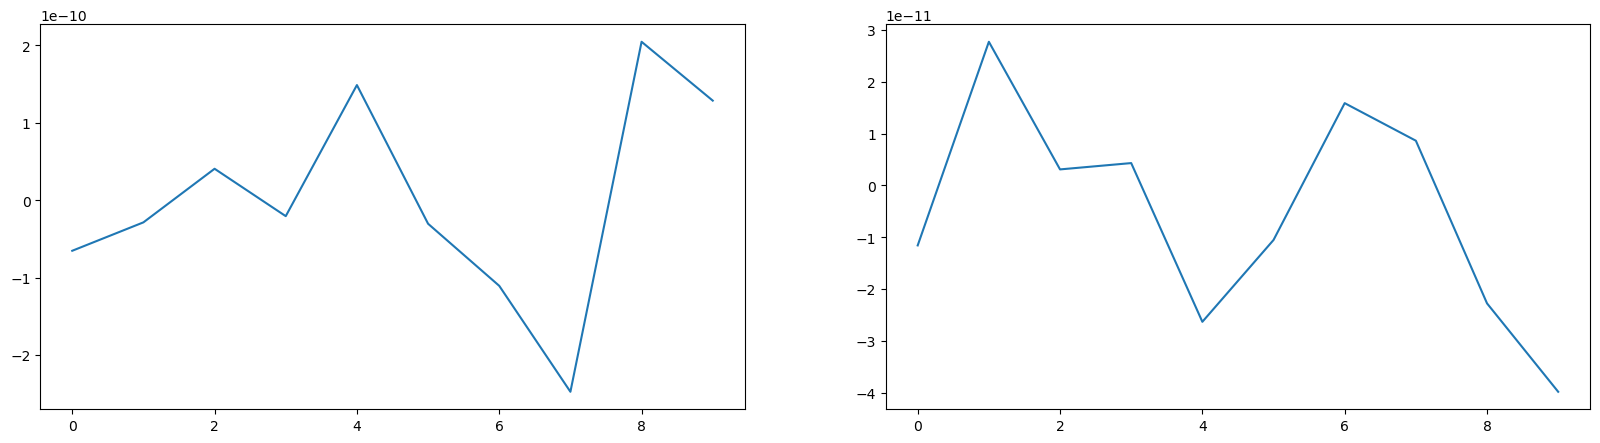

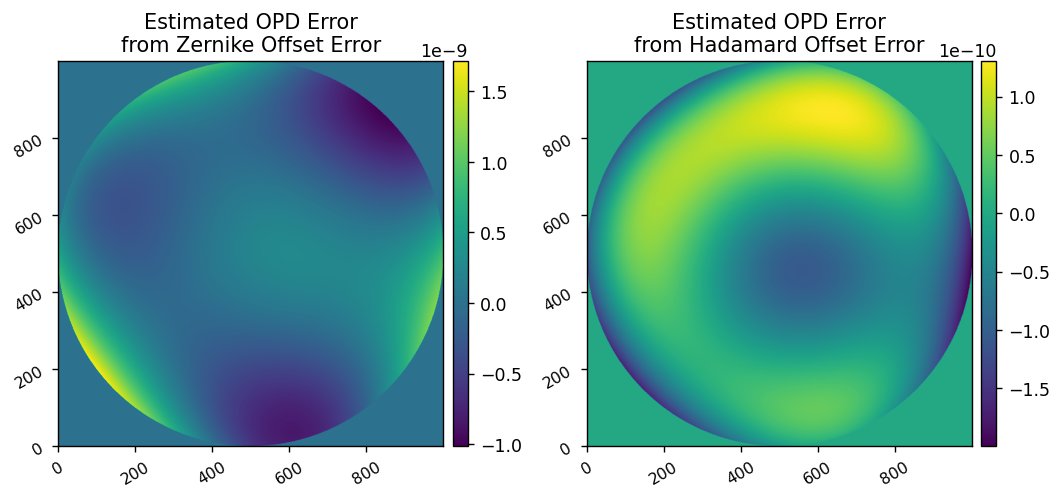

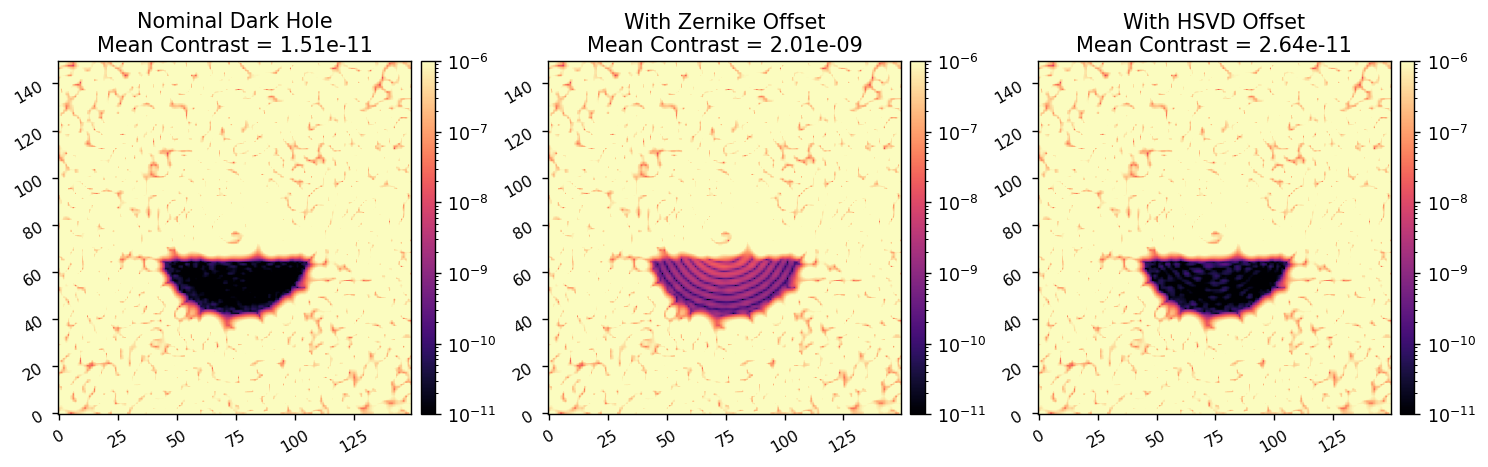

In [16]:
M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']
M.reset_dm()
M.add_dm(dh_command, 3)
M.NCAMLO = 100
ref_offset_truth = M.snap_camlo() - camlo_im_ref

ref_offset_zer = xp.zeros_like(camlo_im_ref)
ref_offset_zer[llowfsc_mask] = z_rm.dot( zer_modal_matrix.dot( dh_command[M.dm_mask] ) / 952 )

hsvd_modal_matrix = hsvd_control_modes[:, M.dm_mask]
ref_offset_hsvd = xp.zeros_like(camlo_im_ref)
ref_offset_hsvd[llowfsc_mask] = hsvd_rm.dot( hsvd_modal_matrix.dot( dh_command[M.dm_mask] ) / 952)

imshow3(
    ref_offset_truth, ref_offset_zer, ref_offset_hsvd,
    'Actual Difference Image', 
    'Predicted Offset with\nZernike Response Matrix', 
    'Predicted Offset with\nHSVD Response Matrix', 
    vmin1=xp.min(ref_offset_truth), vmax1=xp.max(ref_offset_truth), 
    vmin2=xp.min(ref_offset_truth), vmax2=xp.max(ref_offset_truth),
    vmin3=xp.min(ref_offset_truth), vmax3=xp.max(ref_offset_truth),
    # cmap1='bwr', cmap2='bwr', cmap3='bwr',
)

control_matrix = utils.TikhonovInverse(z_rm, 0)

zer_error = llowfsc_mask*ref_offset_truth - ref_offset_zer
zer_coeff = control_matrix.dot(zer_error[llowfsc_mask])
zer_offset_lo_opd = xp.sum( zer_coeff[:, None, None] * wfe_modes, axis=0)
M.PREFPM_OPD = wfe_data['PREFPM_OPD'] + zer_offset_lo_opd
camsci_im_zer_offset = M.snap_camsci()
contrast_zer_offset = xp.mean(camsci_im_zer_offset[dark_hole_mask])

hsvd_error = llowfsc_mask*ref_offset_truth - ref_offset_hsvd
hsvd_coeff = control_matrix.dot(hsvd_error[llowfsc_mask])
hsvd_offset_lo_opd = xp.sum( hsvd_coeff[:, None, None] * wfe_modes, axis=0)
M.PREFPM_OPD = wfe_data['PREFPM_OPD'] + hsvd_offset_lo_opd
camsci_im_hsvd_offset = M.snap_camsci()
contrast_hsvd_offset = xp.mean(camsci_im_hsvd_offset[dark_hole_mask])

plt.figure(figsize=(20,5))
plt.subplot(121)
plt.plot(zer_coeff.get())
plt.subplot(122)
plt.plot(hsvd_coeff.get())
plt.show()

imshow2(
    zer_offset_lo_opd, hsvd_offset_lo_opd,
    'Estimated OPD Error\nfrom Zernike Offset Error', 
    'Estimated OPD Error\nfrom Hadamard Offset Error',
    cmap1='viridis', cmap2='viridis',
)

imshow3(
    camsci_im_dh0, camsci_im_zer_offset, camsci_im_hsvd_offset, 
    f'Nominal Dark Hole\nMean Contrast = {contrast_dh0:.2e}',
    f'With Zernike Offset\nMean Contrast = {contrast_zer_offset:.2e}',
    f'With HSVD Offset\nMean Contrast = {contrast_hsvd_offset:.2e}',
    lognorm=1, 
    vmin1=1e-11, vmax1=1e-6,
    vmin2=1e-11, vmax2=1e-6,
    vmin3=1e-11, vmax3=1e-6,
)


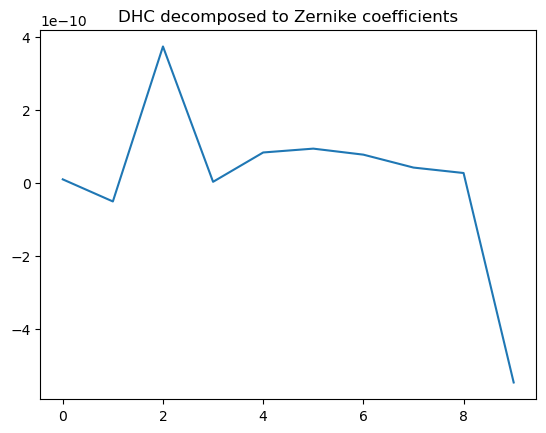

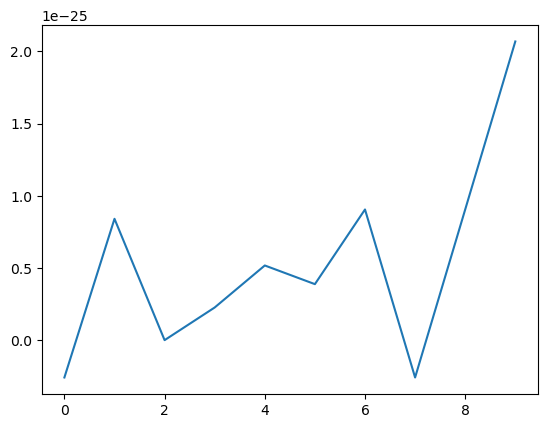

In [115]:
reload(utils)
zer_coeff = utils.lstsq(zernike_modes, dh_command)
zer_coeff_2 = zer_modal_matrix.dot(dh_command[M.dm_mask]) / 952
plt.plot(zer_coeff.get())
plt.title('DHC decomposed to Zernike coefficients')
plt.show()
plt.plot(zer_coeff.get() - zer_coeff_2.get())
plt.show()

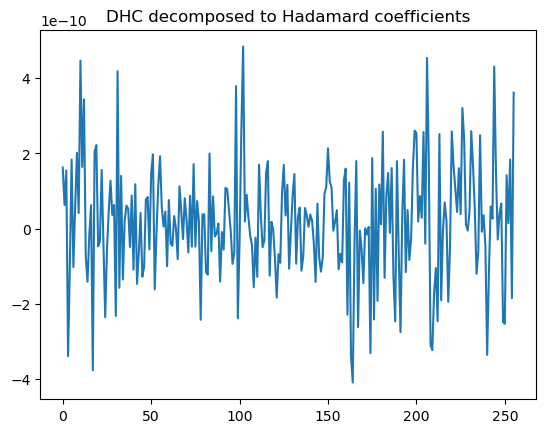

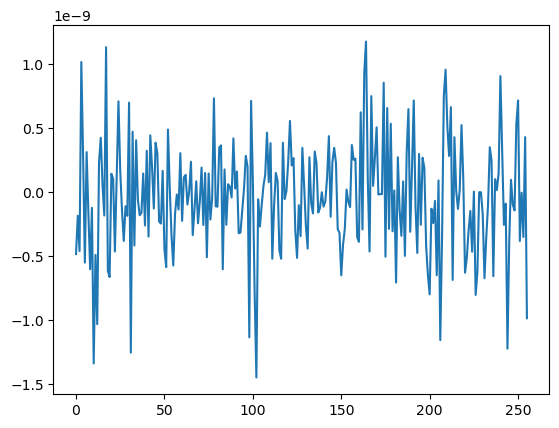

In [74]:
reload(utils)
hsvd_coeff = utils.lstsq(hsvd_control_modes, dh_command)
hsvd_coeff_2 = hsvd_modal_matrix.dot(dh_command[M.dm_mask]) / 256
plt.plot(hsvd_coeff.get())
plt.title('DHC decomposed to Hadamard coefficients')
plt.show()
plt.plot(hsvd_coeff.get() - hsvd_coeff_2.get())
plt.show()

In [16]:
wfe_time_series.shape

(10, 2501)

In [17]:
reload(llowfsc)
M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']
M.reset_dm()
M.add_dm(dh_command, 3)

M.NCAMLO = 1

ref_offset_zer = xp.zeros_like(camlo_im_ref)
ref_offset_zer[llowfsc_mask] = z_rm.dot( zer_modal_matrix.dot( dh_command[M.dm_mask] ) / 952 )

ref_offset_hsvd = xp.zeros_like(camlo_im_ref)
ref_offset_hsvd[llowfsc_mask] = hsvd_rm.dot( hsvd_modal_matrix.dot( dh_command[M.dm_mask] ) / 952)

gains = xp.array(2*[0.75] + 8*[0.2])

llowfsc_dict = llowfsc.run(
    M, 
    wfe_data['PREFPM_AMP'], wfe_data['PREFPM_OPD'],
    camlo_im_ref,
    # xp.zeros_like(camlo_im_ref),
    # ref_offset_zer,
    ref_offset_hsvd,
    llowfsc_mask, 
    control_matrix, 
    # wfe_time_series[:, :100],
    # wfe_time_series[:, :200],
    wfe_time_series, 
    wfe_modes, 
    zernike_modes,
    channel=2,
    gain=gains,  
    leakage=0.0,
    # plot=True, 
    # sleep=1,
    # plot_all=True,
)

llowfsc_dict.update({
    'dark_hole_mask':dark_hole_mask,
    'llowfsc_mask':llowfsc_mask,
})

Starting LLOWFSC control-loop simulation
	Iteration 1250/1250 completed in 63.069s
LLOWFSC simulation complete.


In [18]:
llowfsc_dict.update({
    'dark_hole_mask':dark_hole_mask,
    'llowfsc_mask':llowfsc_mask,
})

utils.save_pickle('sim-data/llowfsc_hsvd_offset_with_noise.pkl', llowfsc_dict)

Saved data to:  sim-data/llowfsc_hsvd_offset_with_noise.pkl


1.1255255261577911e-10


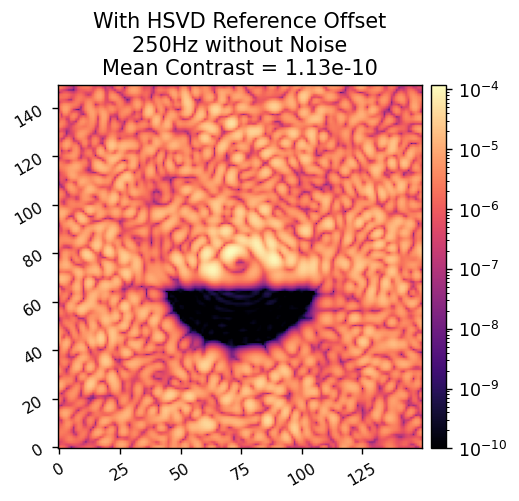

In [18]:
mean_camsci_im = xp.mean(llowfsc_dict['camsci_ims'][50:], axis=0)
mean_contrast = xp.mean( mean_camsci_im[dark_hole_mask])
print(mean_contrast)

imshow1(
    mean_camsci_im, 
    f'With HSVD Reference Offset\n250Hz without Noise\nMean Contrast = {mean_contrast:.2e}', 
    lognorm=1, vmin=1e-10,
)

3.808162191955005e-10


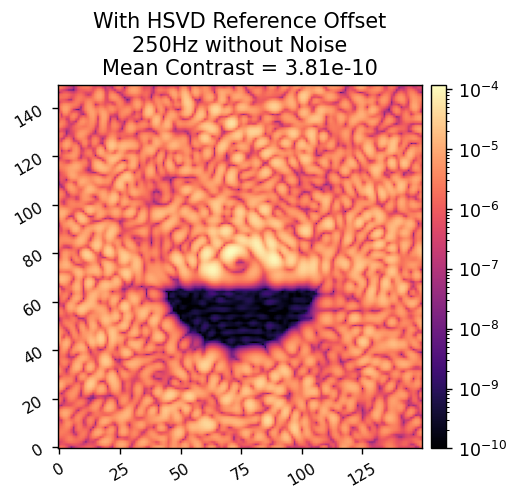

In [36]:
mean_camsci_im = xp.mean(llowfsc_dict['camsci_ims'][50:], axis=0)
mean_contrast = xp.mean( mean_camsci_im[dark_hole_mask])
print(mean_contrast)

imshow1(
    mean_camsci_im, 
    f'With HSVD Reference Offset\n250Hz without Noise\nMean Contrast = {mean_contrast:.2e}', 
    lognorm=1, vmin=1e-10,
)

4.93219406456941e-10


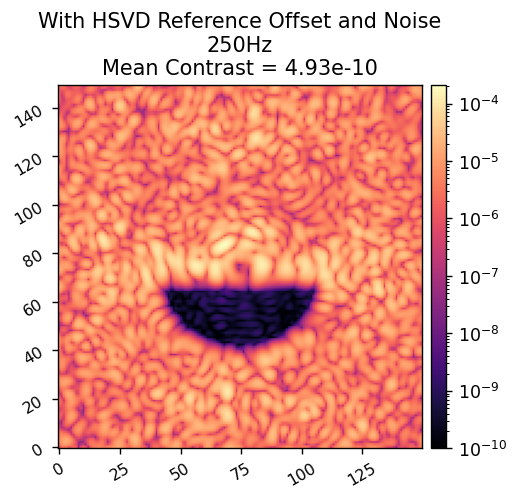

In [55]:
mean_camsci_im = xp.mean(llowfsc_dict['camsci_ims'][50:], axis=0)
mean_contrast = xp.mean( mean_camsci_im[dark_hole_mask])
print(mean_contrast)

imshow1(
    mean_camsci_im, 
    f'With HSVD Reference Offset and Noise\n250Hz\nMean Contrast = {mean_contrast:.2e}', 
    lognorm=1, vmin=1e-10,
)

4.799908105831485e-10


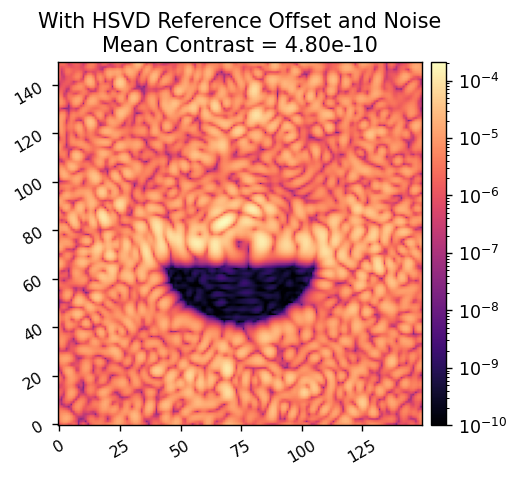

In [21]:
mean_camsci_im = xp.mean(llowfsc_dict['camsci_ims'][50:], axis=0)
mean_contrast = xp.mean( mean_camsci_im[dark_hole_mask])
print(mean_contrast)

imshow1(mean_camsci_im, f'With HSVD Reference Offset and Noise\nMean Contrast = {mean_contrast:.2e}', lognorm=1, vmin=1e-10)

4.838348002078004e-10


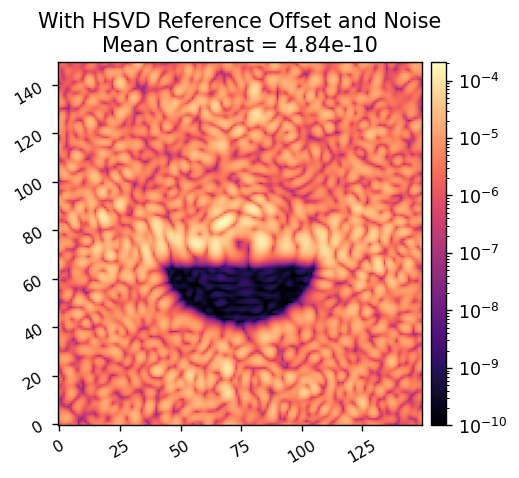

In [19]:
mean_camsci_im = xp.mean(llowfsc_dict['camsci_ims'][50:], axis=0)
mean_contrast = xp.mean( mean_camsci_im[dark_hole_mask])
print(mean_contrast)

imshow1(mean_camsci_im, f'With HSVD Reference Offset and Noise\nMean Contrast = {mean_contrast:.2e}', lognorm=1, vmin=1e-10)

5.582855848463238e-10


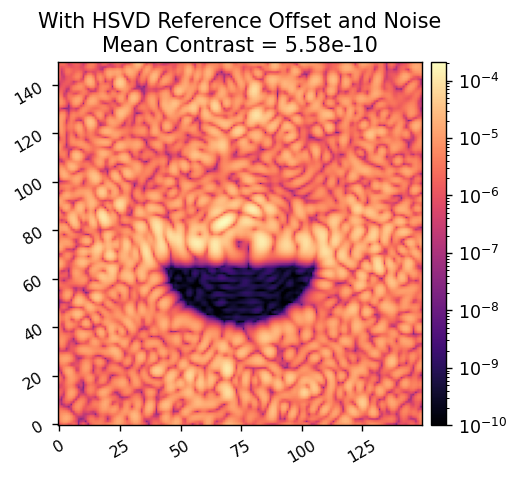

In [17]:
mean_camsci_im = xp.mean(llowfsc_dict['camsci_ims'][50:], axis=0)
mean_contrast = xp.mean( mean_camsci_im[dark_hole_mask])
print(mean_contrast)

imshow1(mean_camsci_im, f'With HSVD Reference Offset and Noise\nMean Contrast = {mean_contrast:.2e}', lognorm=1, vmin=1e-10)